# Tutorial 02b — Envelope Analysis: "Bóc Tách" Tần Số Lỗi Ổ Lăn

> **Đây là notebook quan trọng nhất** — envelope analysis là kỹ thuật cốt lõi của chẩn đoán ổ lăn.

## Cơ Chế Vật Lý Của Lỗi Ổ Lăn

Hãy hình dung viên bi lăn qua vết nứt nhỏ trên rãnh ngoài:
1. Mỗi lần bi đi qua → **một cú va chạm** → xung rung ngắn, mạnh
2. Xung kích thích cấu trúc máy rung ở **tần số cộng hưởng riêng** (2.000–5.000 Hz)
3. Xung lặp lại theo chu kỳ BPFO = 107 Hz → cứ 9.3 ms có 1 xung

**Vấn đề:** FFT thông thường chỉ thấy "nhiều năng lượng ở dải cao" nhưng không thấy chu kỳ 107 Hz.

**Giải pháp — 4 bước Envelope Analysis:**
1. **Bandpass** quanh vùng cộng hưởng (2.000–5.000 Hz)
2. **Hilbert Transform** → lấy đường bao biên độ (envelope)
3. **FFT của envelope** → đỉnh tại tần số lặp = BPFO/BPFI/BSF
4. **So sánh** với tần số đặc trưng → kết luận loại lỗi

> 📌 **Từ khóa:** "Envelope spectrum = tín hiệu sau khi giải điều chế. Giống nghe nhịp tim — lọc tiếng ồn, chỉ giữ chu kỳ đập."

---

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
os.makedirs('../figures', exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert
from src.config import *
from src.signal_utils import load_one_sample_per_class, envelope_spectrum

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
samples = load_one_sample_per_class(domain='0HP')
print("✅ Dữ liệu đã load.")

✅ Dữ liệu đã load.


## 1. Minh Họa 4 Bước Envelope Analysis

Lấy 1 mẫu tín hiệu **lỗi rãnh ngoài (OR)** để minh họa từng bước.

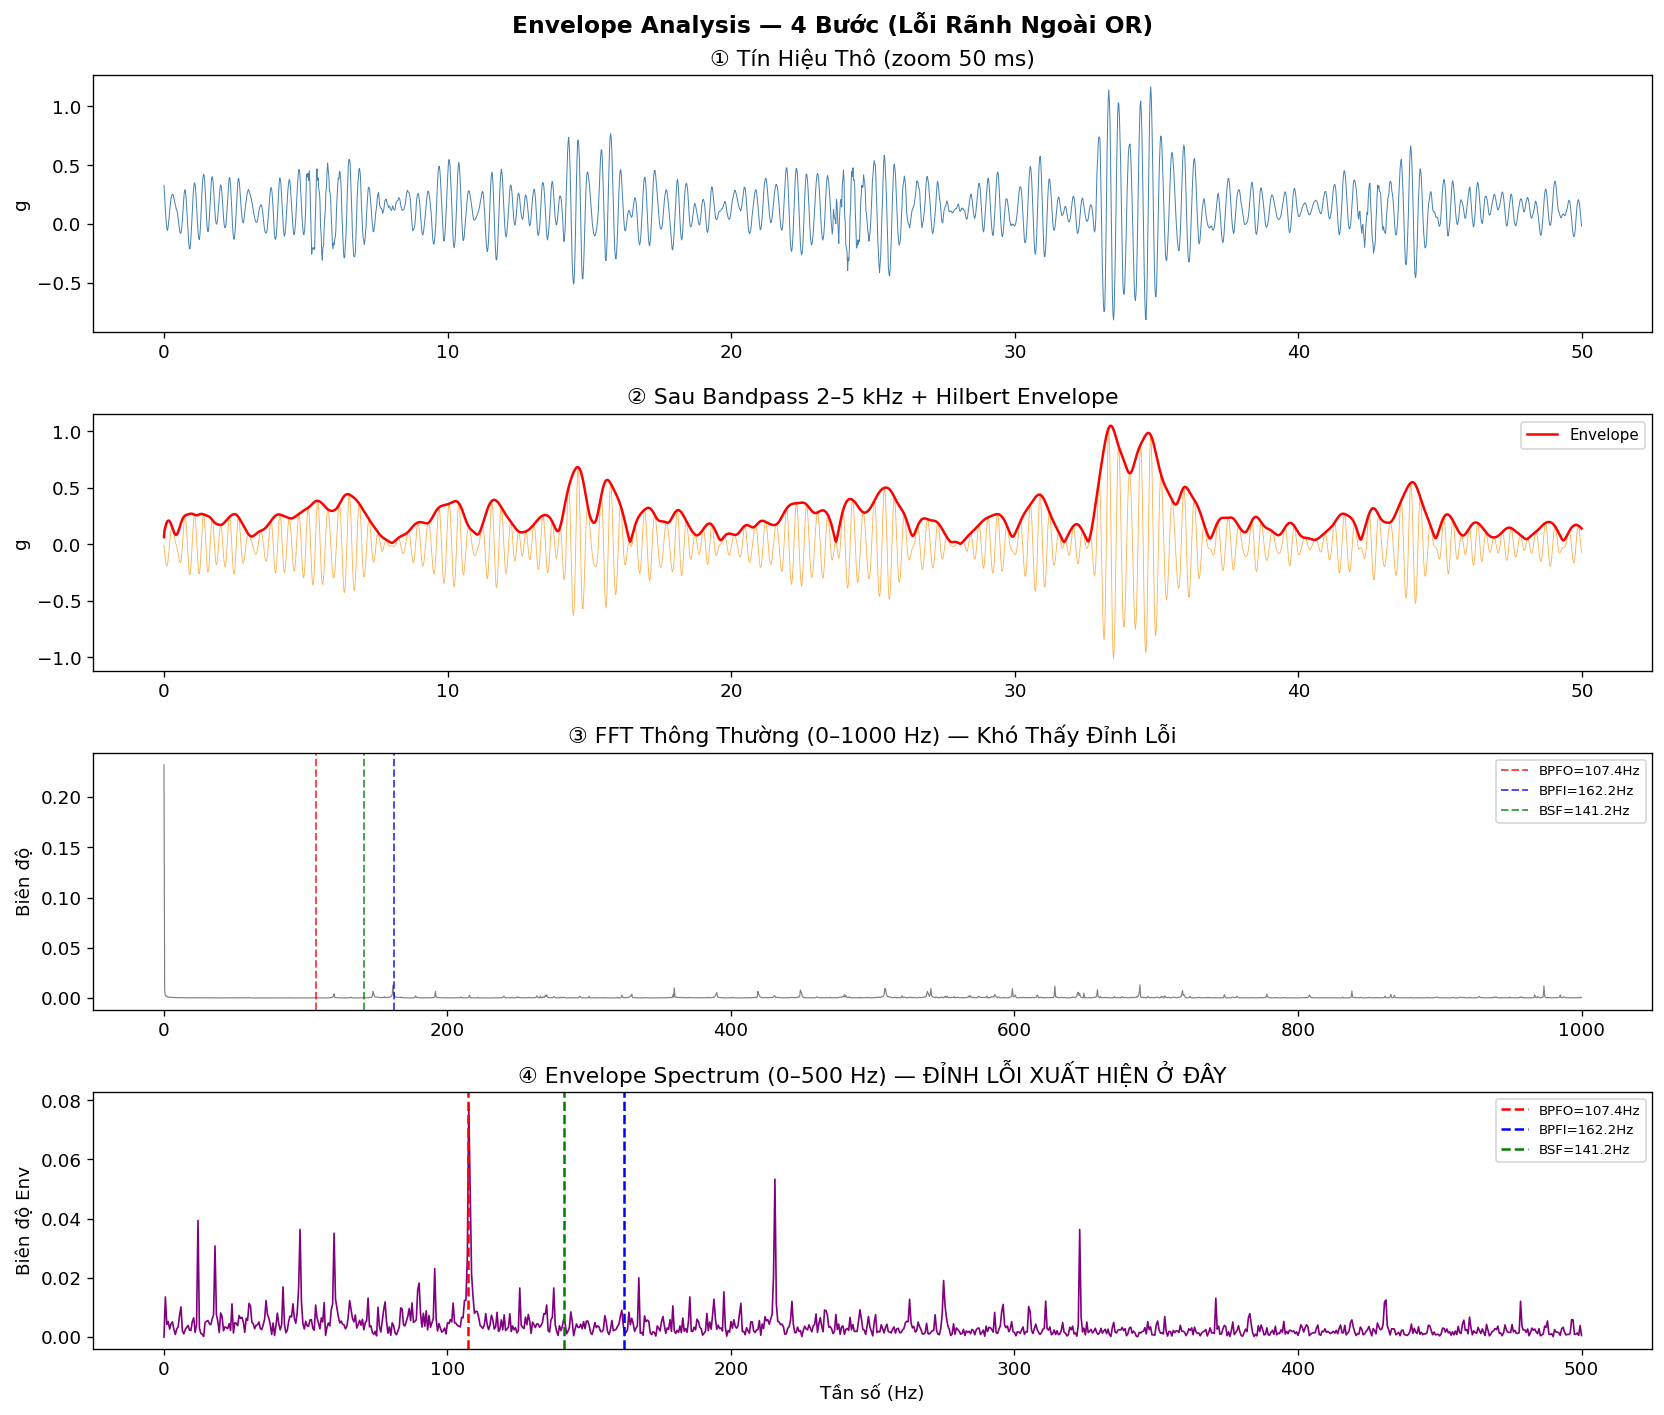

In [2]:
sig_or = samples.get('OR', list(samples.values())[0])
chunk = sig_or[:FS*2]  # 2 giây
t = np.arange(len(chunk)) / FS * 1000
zoom = int(0.05 * FS)  # 50 ms

# Bước 1: Bandpass
nyq = FS / 2
b, a = butter(4, [F_RES_LOW/nyq, F_RES_HIGH/nyq], btype='band')
filtered = filtfilt(b, a, chunk)
envelope = np.abs(hilbert(filtered))

# Bước 3: FFT envelope
n = len(envelope)
env_fft = np.abs(np.fft.fft(envelope - np.mean(envelope))[:n//2]) * 2/n
env_freqs = np.fft.fftfreq(n, 1/FS)[:n//2]

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Envelope Analysis — 4 Bước (Lỗi Rãnh Ngoài OR)', fontsize=14, fontweight='bold')

# Bước 0: Waveform gốc
axes[0].plot(t[:zoom], chunk[:zoom], lw=0.6, color='steelblue')
axes[0].set(title='① Tín Hiệu Thô (zoom 50 ms)', ylabel='g')

# Bước 1+2: Sau bandpass + envelope
axes[1].plot(t[:zoom], filtered[:zoom], lw=0.5, color='darkorange', alpha=0.7)
axes[1].plot(t[:zoom], envelope[:zoom], lw=1.5, color='red', label='Envelope')
axes[1].set(title='② Sau Bandpass 2–5 kHz + Hilbert Envelope', ylabel='g')
axes[1].legend(fontsize=9)

# Bước 2: FFT thông thường
freqs_raw = np.fft.fftfreq(n, 1/FS)[:n//2]
fft_raw = np.abs(np.fft.fft(chunk)[:n//2]) * 2/n
mask = freqs_raw <= 1000
axes[2].plot(freqs_raw[mask], fft_raw[mask], lw=0.7, color='gray')
for f, nm, c in [(BPFO,'BPFO','red'), (BPFI,'BPFI','blue'), (BSF,'BSF','green')]:
    axes[2].axvline(f, ls='--', lw=1.2, color=c, alpha=0.7, label=f'{nm}={f}Hz')
axes[2].set(title='③ FFT Thông Thường (0–1000 Hz) — Khó Thấy Đỉnh Lỗi', ylabel='Biên độ')
axes[2].legend(fontsize=8)

# Bước 3: Envelope spectrum
mask_env = env_freqs <= 500
axes[3].plot(env_freqs[mask_env], env_fft[mask_env], lw=1, color='purple')
for f, nm, c in [(BPFO,'BPFO','red'), (BPFI,'BPFI','blue'), (BSF,'BSF','green')]:
    axes[3].axvline(f, ls='--', lw=1.5, color=c, label=f'{nm}={f}Hz')
axes[3].set(title='④ Envelope Spectrum (0–500 Hz) — ĐỈNH LỖI XUẤT HIỆN Ở ĐÂY', xlabel='Tần số (Hz)', ylabel='Biên độ Env')
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/envelope_4steps_OR.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. So Sánh Envelope Spectrum — 4 Trạng Thái

Hình quan trọng nhất để giảng dạy: cột trái FFT thông thường, cột phải envelope spectrum.

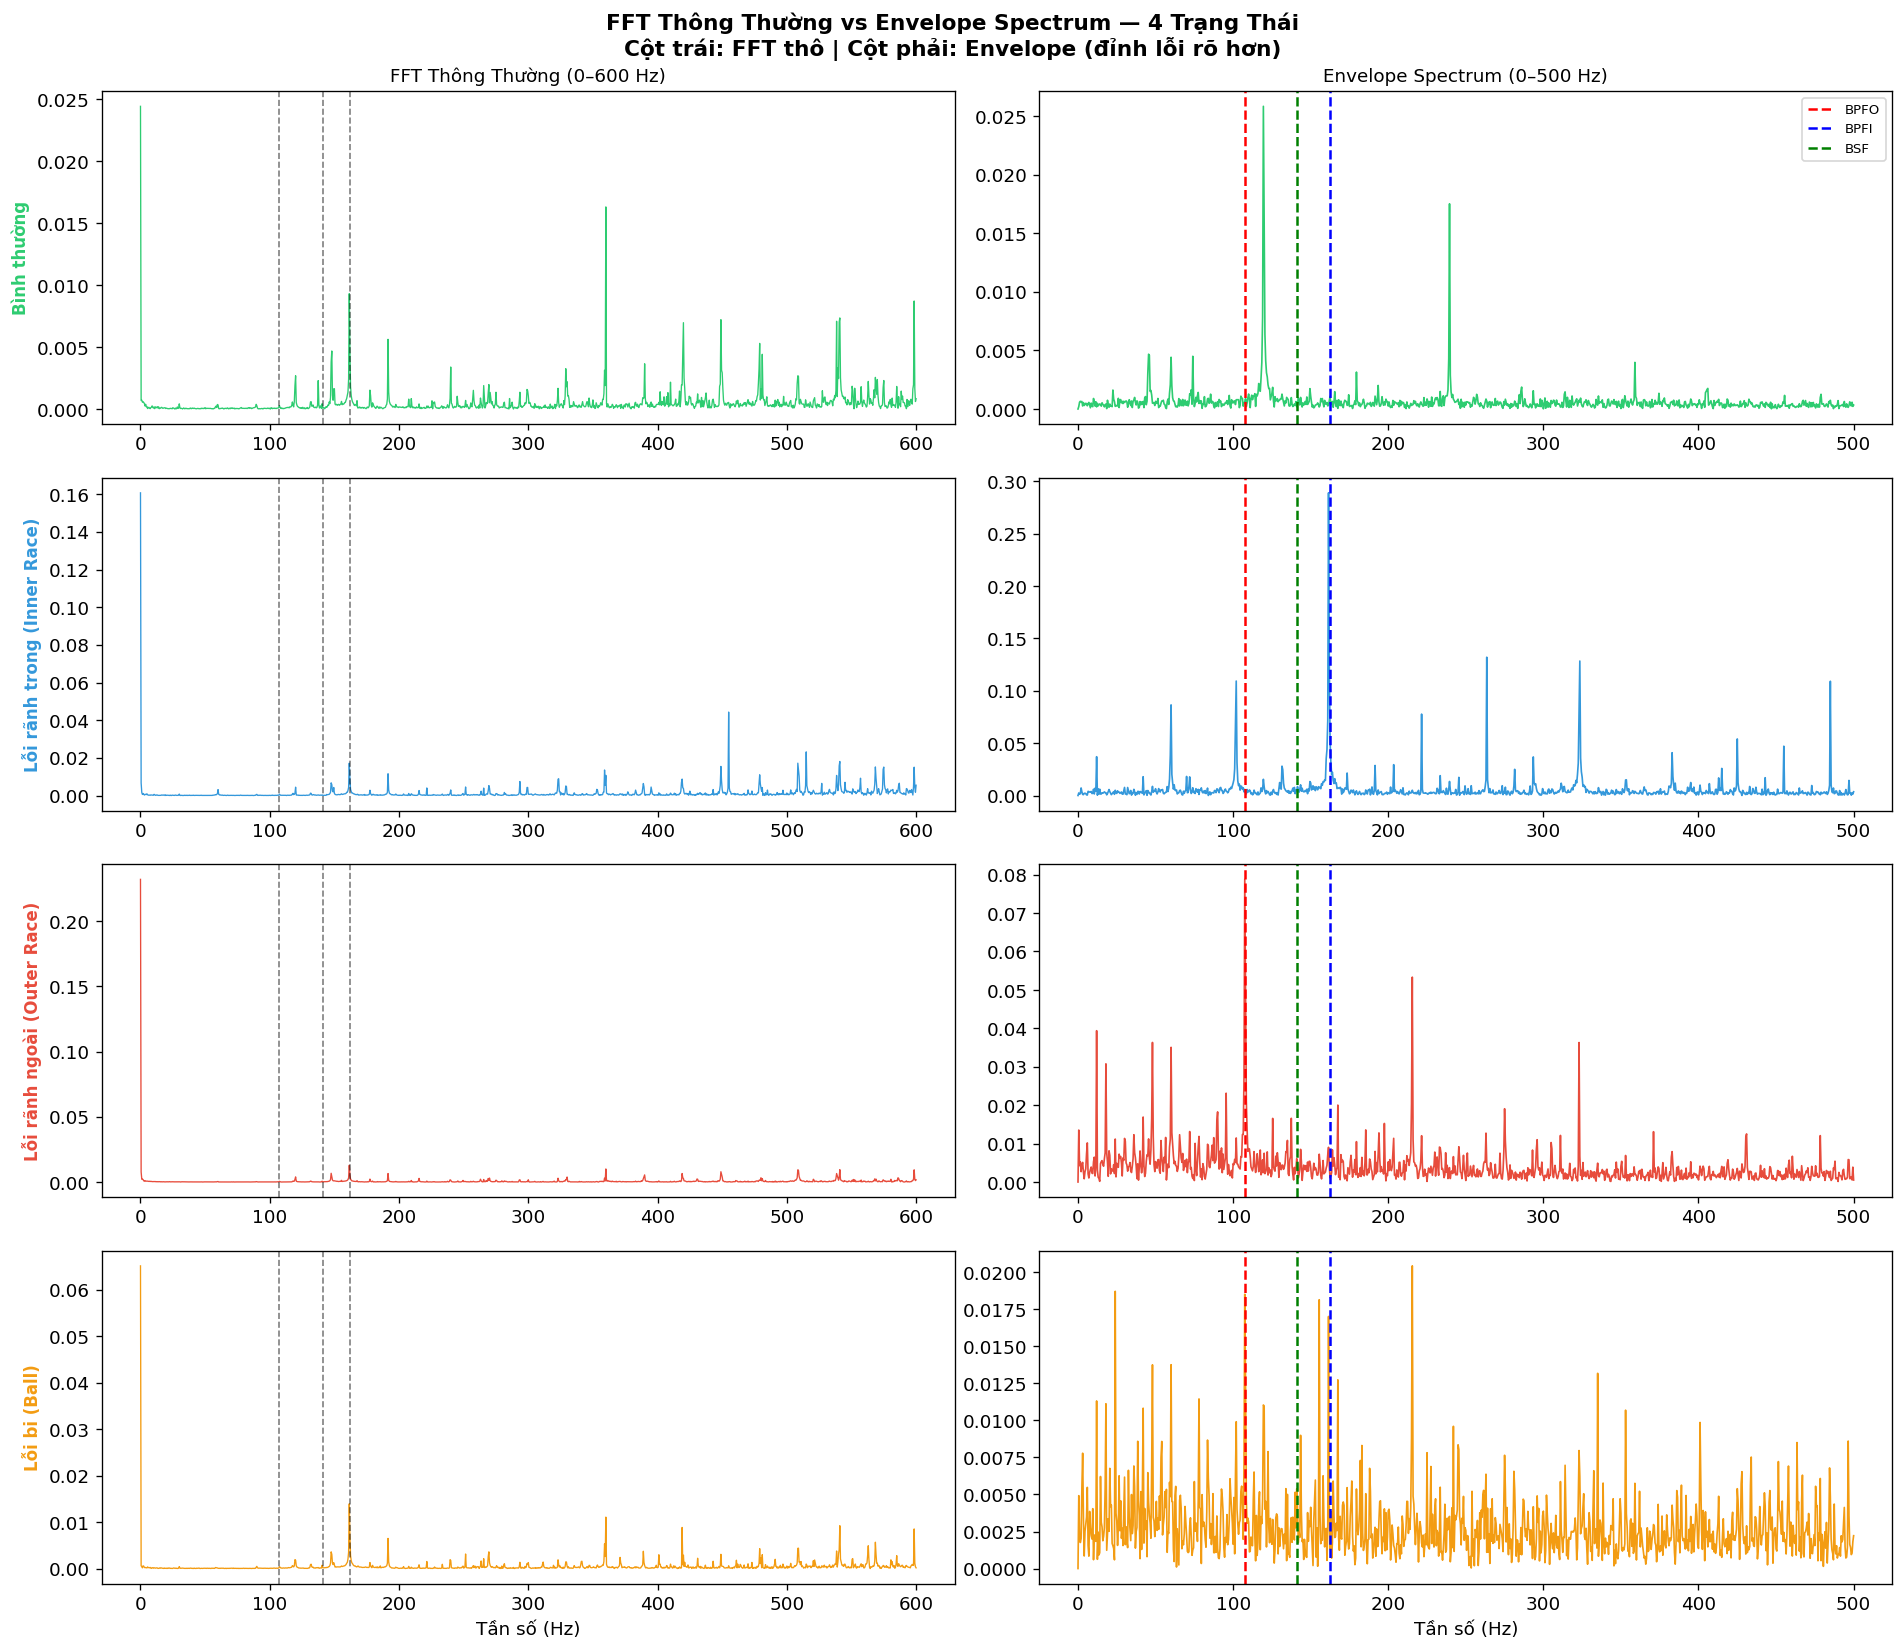

In [3]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('FFT Thông Thường vs Envelope Spectrum — 4 Trạng Thái\n'
             'Cột trái: FFT thô | Cột phải: Envelope (đỉnh lỗi rõ hơn)', fontsize=13, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    if cls not in samples: continue
    sig = samples[cls][:FS*2]
    n = len(sig)
    color = CLASS_COLORS[cls]

    # Cột trái: FFT
    freqs_raw = np.fft.fftfreq(n, 1/FS)[:n//2]
    fft_raw = np.abs(np.fft.fft(sig)[:n//2]) * 2/n
    mask = freqs_raw <= 600
    axes[row, 0].plot(freqs_raw[mask], fft_raw[mask], lw=0.8, color=color)
    for f, nm in [(BPFO,'BPFO'), (BPFI,'BPFI'), (BSF,'BSF')]:
        axes[row, 0].axvline(f, ls='--', lw=1, alpha=0.5, color='k')
    axes[row, 0].set_ylabel(CLASS_DESC[cls], fontsize=10, color=color, fontweight='bold')
    if row == 0: axes[row, 0].set_title('FFT Thông Thường (0–600 Hz)', fontsize=11)
    if row == 3: axes[row, 0].set_xlabel('Tần số (Hz)')

    # Cột phải: Envelope
    freqs_env, env_fft, _, _ = envelope_spectrum(sig, FS)
    mask_env = freqs_env <= 500
    axes[row, 1].plot(freqs_env[mask_env], env_fft[mask_env], lw=1, color=color)
    for f, nm, c in [(BPFO,'BPFO','red'), (BPFI,'BPFI','blue'), (BSF,'BSF','green')]:
        axes[row, 1].axvline(f, ls='--', lw=1.5, color=c, label=nm if row==0 else '')
    if row == 0:
        axes[row, 1].set_title('Envelope Spectrum (0–500 Hz)', fontsize=11)
        axes[row, 1].legend(fontsize=8, loc='upper right')
    if row == 3: axes[row, 1].set_xlabel('Tần số (Hz)')

plt.tight_layout()
plt.savefig('../figures/envelope_comparison_4states.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔎 Đọc Kết Quả Envelope Spectrum Như Kỹ Sư Hiện Trường

| Trạng thái | FFT thông thường | Envelope spectrum | Kết luận |
|---|---|---|---|
| **Normal** | Phổ phẳng | Phổ phẳng — không có xung lặp lại | ✅ Ổ lăn bình thường |
| **OR** | Đỉnh nhỏ rải rác, khó đọc | **Đỉnh rõ tại 107 Hz (BPFO)** | ⚠️ Lỗi rãnh ngoài — cứ 9.3ms có 1 xung |
| **IR** | Tương tự normal | **Đỉnh tại 162 Hz (BPFI)** + sidebands ±1X | 🔴 Lỗi rãnh trong — thường diễn biến nhanh hơn OR |
| **Ball** | Gần giống normal | **Đỉnh tại 141 Hz (BSF)** nhưng nhỏ hơn | 🟡 Lỗi bi — khó phát hiện sớm |

**Tại sao OR dễ phát hiện nhất?** Vết lỗi nằm cố định ở vùng tải → bi nào cũng đi qua → xung rất đều → đỉnh BPFO sắc nét.

**Tại sao IR khó hơn?** Vết lỗi quay theo trục → lúc trong vùng tải xung mạnh, lúc ra ngoài xung nhỏ → bị "điều chế" → thấy sidebands ±1X.

---
*Tutorial 02b hoàn tất. Tiếp theo: Tutorial 03 — Feature Engineering.*